In [18]:
import pandas as pd

In [19]:
dataset=pd.read_csv("PrePlacement.csv")

In [38]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          148 non-null    object 
 1   ssc_p           148 non-null    float64
 2   ssc_b           148 non-null    object 
 3   hsc_p           148 non-null    float64
 4   hsc_b           148 non-null    object 
 5   hsc_s           148 non-null    object 
 6   degree_p        148 non-null    float64
 7   degree_t        148 non-null    object 
 8   workex          148 non-null    object 
 9   etest_p         148 non-null    float64
 10  specialisation  148 non-null    object 
 11  mba_p           148 non-null    float64
 12  status          148 non-null    object 
 13  salary          148 non-null    float64
dtypes: float64(6), object(8)
memory usage: 17.3+ KB


In [21]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [22]:
dataset.cov(numeric_only=True)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,3870.000000,-52.641355,-58.106028,-40.413645,52.556168,8.102336,3.616177e+05
ssc_p,-52.641355,117.228377,60.348373,42.897137,37.659225,24.535952,2.877739e+04
hsc_p,-58.106028,60.348373,118.755706,34.819820,35.461678,22.555846,6.697772e+04
degree_p,-40.413645,42.897137,34.819820,54.151103,21.929469,17.272020,-1.173995e+04
etest_p,52.556168,37.659225,35.461678,21.929469,176.251018,16.886973,2.287876e+05
mba_p,8.102336,24.535952,22.555846,17.272020,16.886973,34.028376,9.624979e+04
salary,361617.668689,28777.386468,66977.716032,-11739.948520,228787.619507,96249.789024,8.734295e+09


In [23]:
dataset.corr(numeric_only=True)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.063764
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.063764,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


In [24]:
dataset.drop('sl_no',inplace=True,axis=1)

In [25]:
dataset

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [26]:
import seaborn as sns

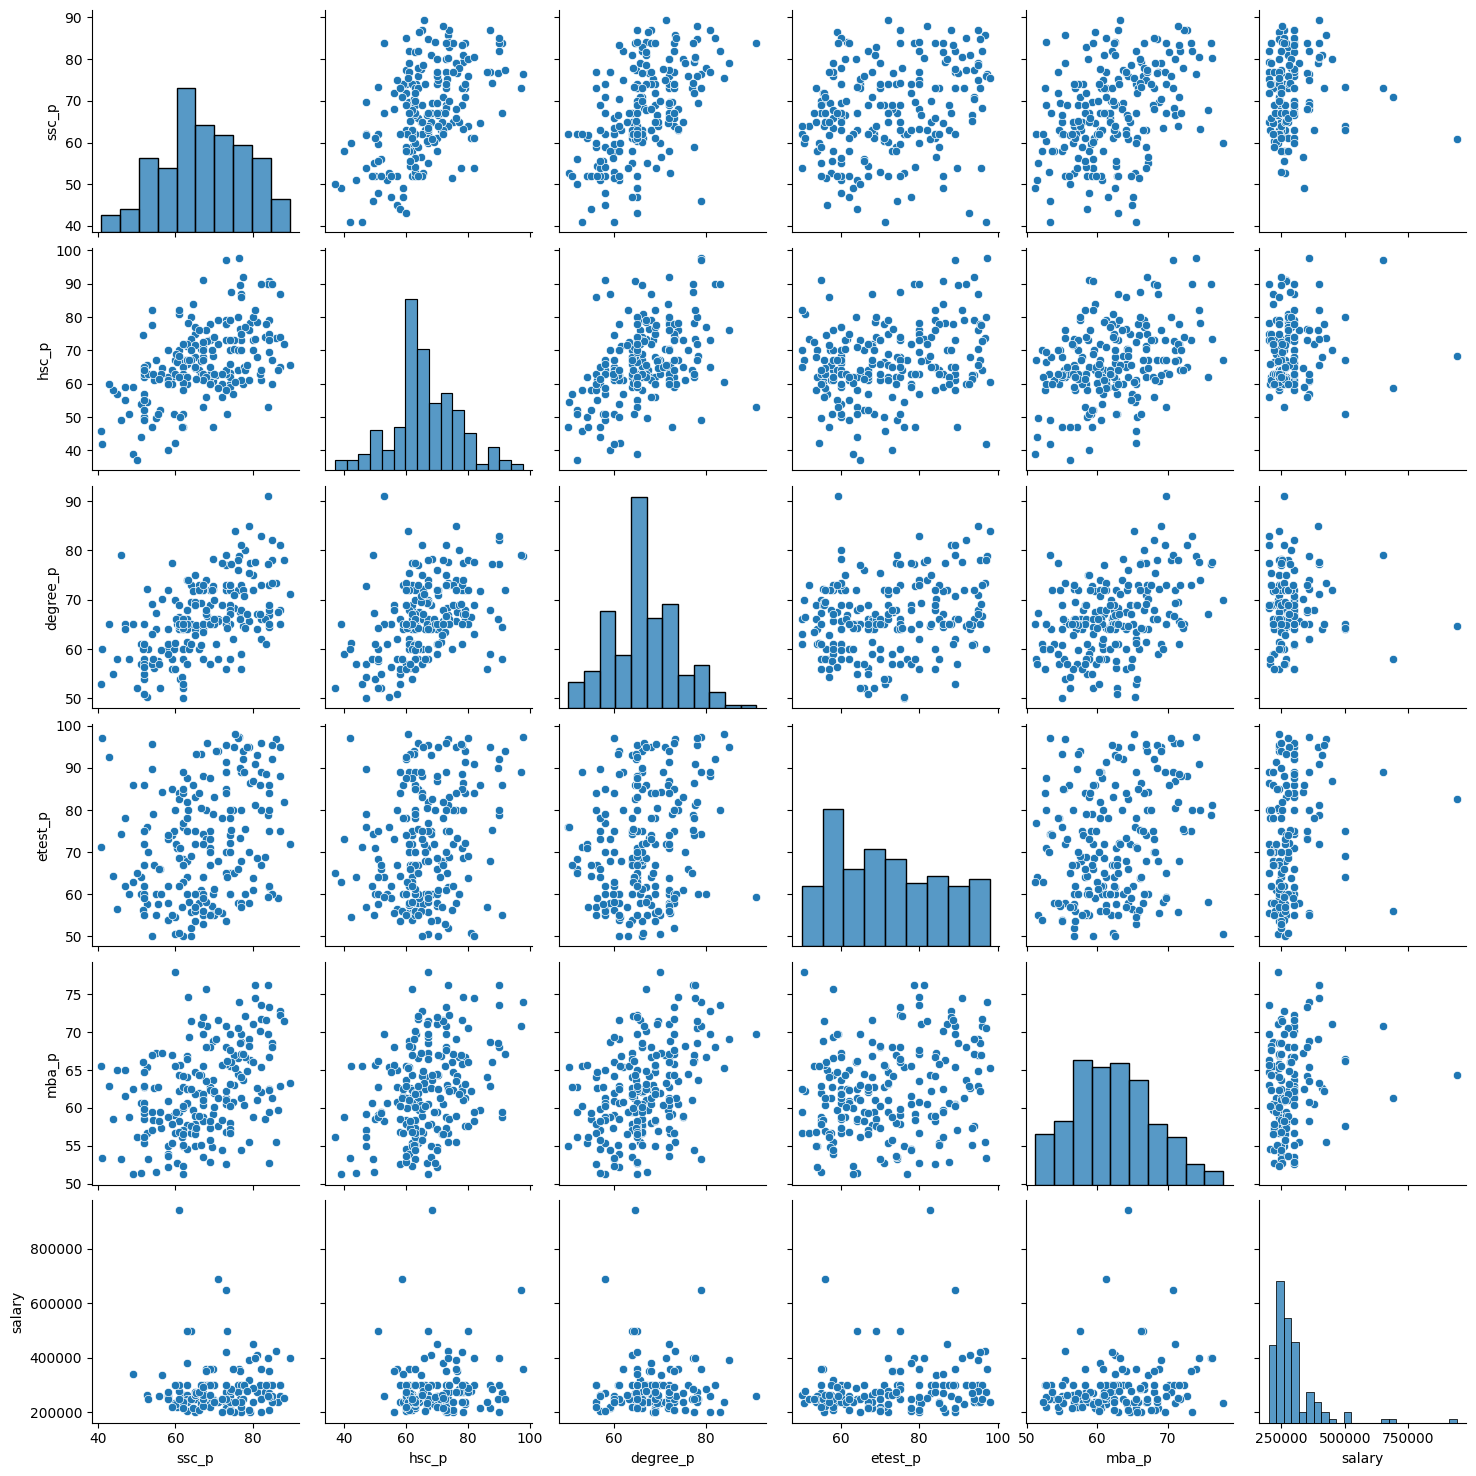

In [27]:
sns.pairplot(dataset)

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)


In [29]:
# calc_vif(dataset[["etest_p","salary"]])

#### Independant Sample- Unpaired T Test
Diferrent Group(Male, Female) but same contion(salary)

In [30]:
dataset[dataset['gender']=='F']["salary"]

6           NaN
12          NaN
13     218000.0
15     200000.0
17          NaN
         ...   
197    260000.0
198         NaN
204    210000.0
208         NaN
213    204000.0
Name: salary, Length: 76, dtype: float64

In [31]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['salary']
female = dataset[dataset['gender']=='F']['salary']
#print(male)
ttest_ind(male, female)

TtestResult(statistic=np.float64(1.9448521615505496), pvalue=np.float64(0.053714668806405776), df=np.float64(146.0))

#### Dependant Sample-Paired T_Test
Same Group(Male) but Different Condition(ssc_p,hsc_p)


In [32]:
from scipy.stats import ttest_rel
#dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['ssc_p']
male1 = dataset[dataset['gender']=='M']['hsc_p']
ttest_rel(male, male1)


TtestResult(statistic=np.float64(0.881726473207718), pvalue=np.float64(0.38006050142386016), df=np.int64(99))

In [33]:
# Hypothesis Testing

In [34]:
#Statement: Test whether SSC_p of male and HSC_P of Male is Same?

In [35]:
#Null hypothesis=There is no similarity between 10th pass mark of male  and 12th pass mark of male

In [36]:
from scipy.stats import ttest_rel
#dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['ssc_p']
male1 = dataset[dataset['gender']=='M']['hsc_p']
ttest_rel(male, male1)


TtestResult(statistic=np.float64(0.881726473207718), pvalue=np.float64(0.38006050142386016), df=np.int64(99))

# Reject Null hypothesis p<0.05
# Accept Null Hypothesi and Reject Alternate hypothsis

# ANAVO : Analysis of Variance

In [37]:
import scipy.stats as stats

stats.f_oneway(dataset['ssc_p'],dataset['hsc_p'],dataset['degree_p'])


F_onewayResult(statistic=np.float64(4.866998084927855), pvalue=np.float64(0.008114829524764137))